# 03 - Exploratory Data Analysis (EDA)

**Goal**: Visualize distributions, trends, and correlations in the cleaned dataset.
Answer initial research questions and identify patterns for ML modeling.

**Learning concepts**: Descriptive statistics, distribution analysis, correlation,
time series visualization, box plots for group comparison.

**Research themes explored**:
- Theme 1 (Salary): What do salary distributions look like across experience levels?
- Theme 2 (Ghost Jobs): How long do postings stay open? What's the distribution of `days_open`?
- Theme 3 (Entry-Level): What experience levels dominate the dataset?
- Theme 4 (Engagement): What drives the applies-to-views ratio?

---

In [1]:
print(f"Importing libraries...")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from talentlens.config import POSTINGS_CLEAN_PARQUET
from talentlens.plots import (
    plot_top_categories, plot_distribution, plot_box_by_category,
    plot_time_series, plot_correlation_heatmap, save_fig,
)

pd.set_option('display.max_columns', None)
%matplotlib inline

print(f"[SUCCESS] Libraries imported successfully.")

Importing libraries...
[SUCCESS] Libraries imported successfully.


In [2]:
# Load the cleaned dataset (fast from Parquet!)
if not POSTINGS_CLEAN_PARQUET.exists():
    raise FileNotFoundError(
        "postings_clean.parquet not found! "
        "Run notebook 02-mp-data-cleaning.ipynb first."
    )

df = pd.read_parquet(POSTINGS_CLEAN_PARQUET)
print(f"Loaded {len(df):,} cleaned postings\n")

df.info()

Loaded 123,842 cleaned postings

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123842 entries, 0 to 123841
Data columns (total 37 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   job_id                      123842 non-null  int64         
 1   company_name                122124 non-null  object        
 2   title                       123842 non-null  object        
 3   description                 123842 non-null  object        
 4   max_salary                  29792 non-null   float64       
 5   pay_period                  36072 non-null   object        
 6   location                    123842 non-null  object        
 7   company_id                  122126 non-null  float64       
 8   views                       122153 non-null  float64       
 9   med_salary                  6280 non-null    float64       
 10  min_salary                  29792 non-null   float64       
 11  format

## 1. Job Title Distribution

What kinds of jobs dominate the dataset?

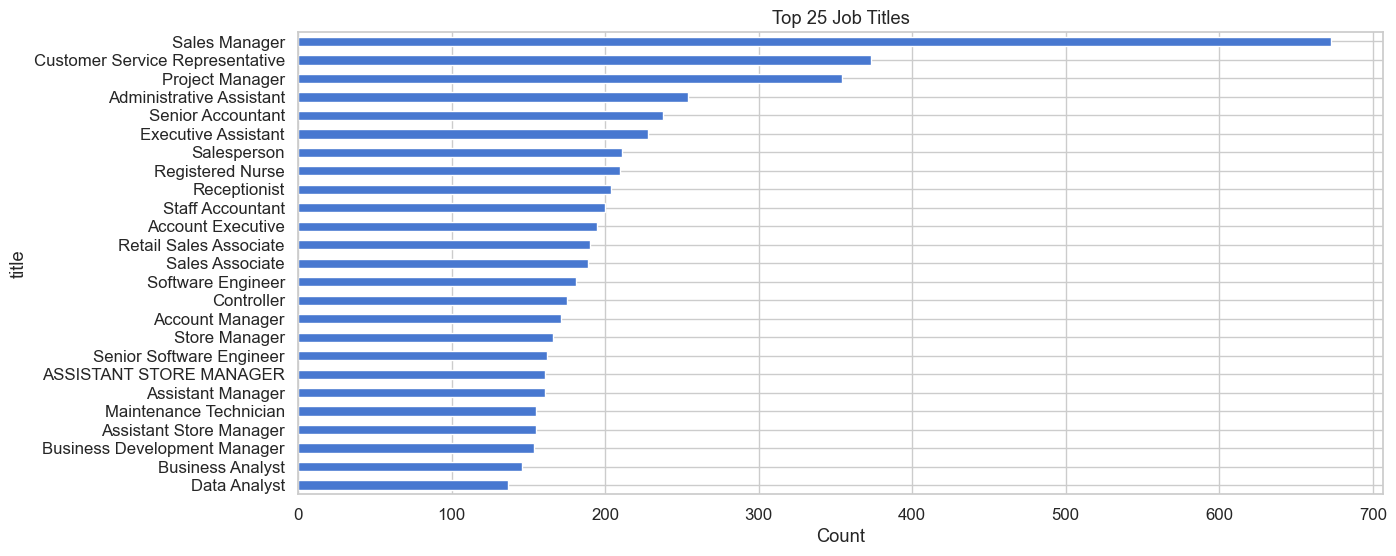

In [3]:
plot_top_categories(
    df['title'],
    title='Top 25 Job Titles',
    top_n=25,
    save_name='eda_top_job_titles'
)
plt.show()

## 2. Experience Level Distribution

**Research Theme 3**: What proportion of jobs are labeled "Entry level"?

Experience Level Counts:
experience_level
Mid-Senior level    41489
Entry level         36708
Unknown             29402
Associate            9826
Director             3746
Internship           1449
Executive            1222
Name: count, dtype: int64

Percentages:
experience_level
Mid-Senior level    33.5
Entry level         29.6
Unknown             23.7
Associate            7.9
Director             3.0
Internship           1.2
Executive            1.0
Name: count, dtype: float64


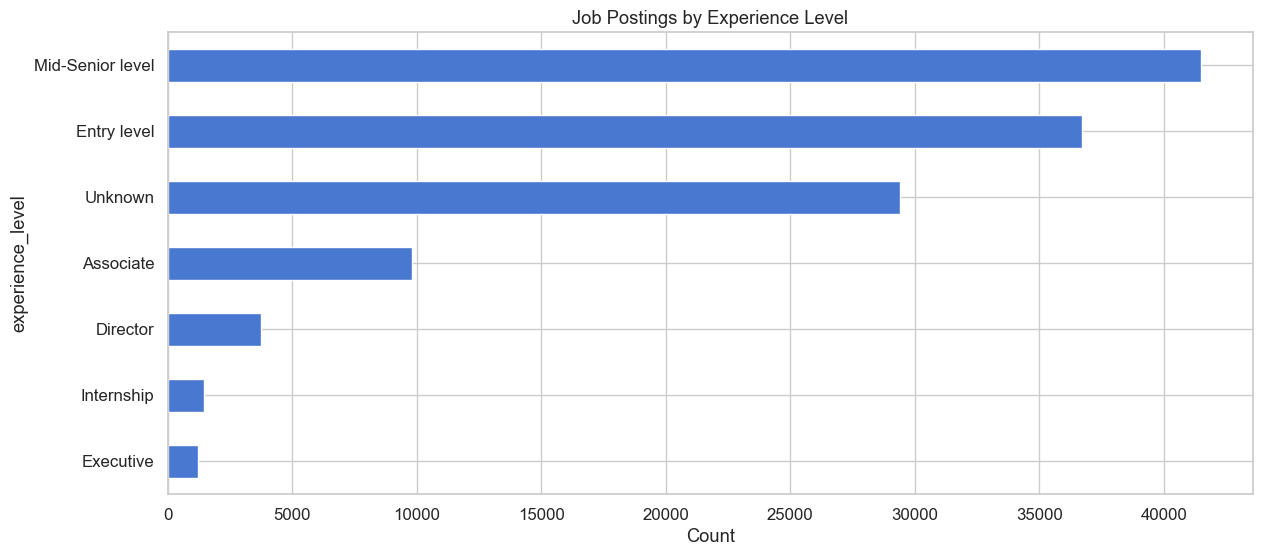

In [4]:
print("Experience Level Counts:")
exp_counts = df['experience_level'].value_counts()
print(exp_counts)
print(f"\nPercentages:")
print((exp_counts / len(df) * 100).round(1))

plot_top_categories(
    df['experience_level'],
    title='Job Postings by Experience Level',
    top_n=10,
    save_name='eda_experience_levels'
)
plt.show()

## 3. Salary Distributions

**Research Theme 1**: What do salaries look like? How do they vary by experience level and remote status?

Postings with salary data: 6,280 (5.1%)


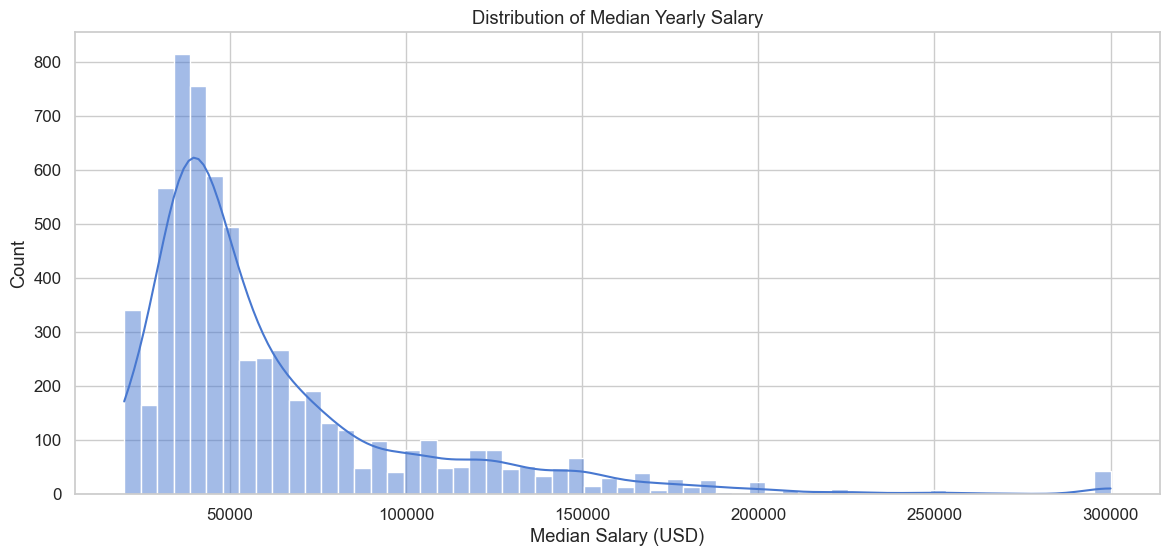


Salary statistics:
count       6280.0
mean       63121.0
std        52417.0
min            0.0
25%        37440.0
50%        47840.0
75%        72800.0
max      1248000.0
Name: med_salary_yearly, dtype: float64


In [5]:
# Filter to postings with salary data
df_salary = df[df['med_salary_yearly'].notna()].copy()
print(f"Postings with salary data: {len(df_salary):,} ({len(df_salary)/len(df)*100:.1f}%)")

# Overall salary distribution (clip outliers for visualization)
plot_distribution(
    df_salary['med_salary_yearly'],
    title='Distribution of Median Yearly Salary',
    xlabel='Median Salary (USD)',
    clip=(20_000, 300_000),
    bins=60,
    save_name='eda_salary_distribution'
)
plt.show()

print("\nSalary statistics:")
print(df_salary['med_salary_yearly'].describe().round(0))

### How to read this histogram

- **X-axis**: Salary bins (e.g., $40K-$60K, $60K-$80K, ...)
- **Y-axis**: How many postings fall in that bin
- **The peak** (tallest bar): The most common salary range — this is where the majority of jobs are priced
- **The tail** (bars trailing to the right): High-salary outliers — executive/specialist roles
- **The KDE line** (smooth curve): A smoothed estimate of the distribution shape. If it's right-skewed (long tail to the right), it means a few jobs pay very high salaries but most are clustered in the middle

**Key question**: Is the distribution normal (bell-shaped) or skewed? Skewed data may need log-transformation for ML models.

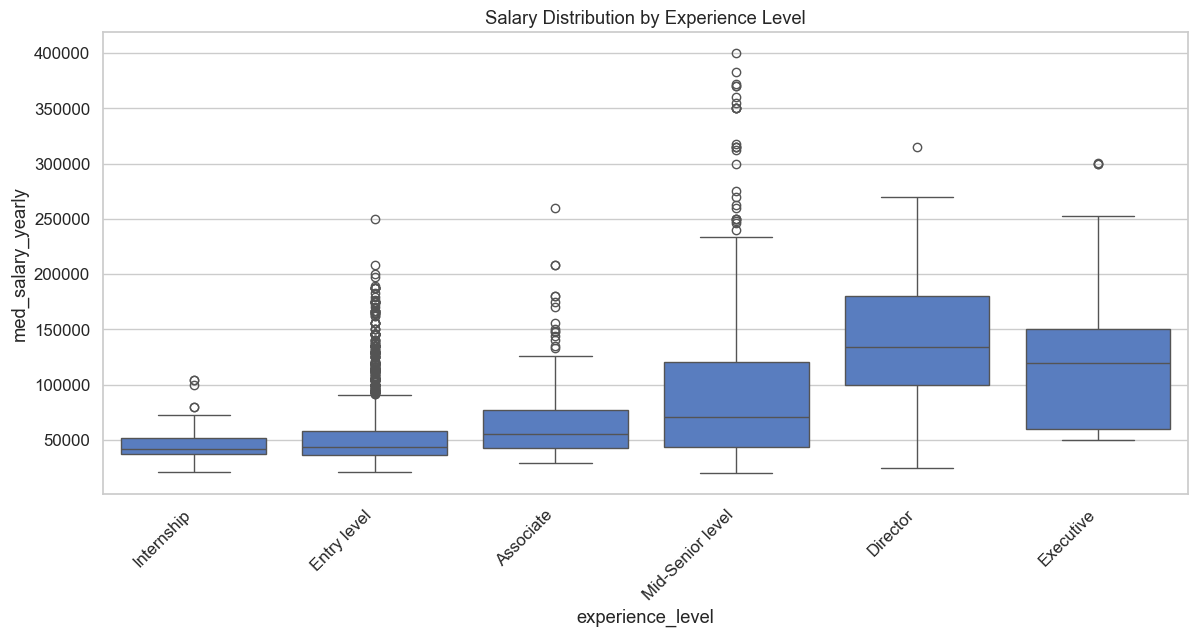

In [6]:
# Salary by experience level
exp_order = ['Internship', 'Entry level', 'Associate', 'Mid-Senior level', 'Director', 'Executive']

# Filter to only experience levels that exist in the data
available_levels = df_salary['experience_level'].unique()
filtered_order = []
for e in exp_order:
    if e in available_levels:
        filtered_order.append(e)
exp_order = filtered_order

plot_box_by_category(
    df_salary[df_salary['med_salary_yearly'].between(20_000, 400_000)],
    x='experience_level',
    y='med_salary_yearly',
    title='Salary Distribution by Experience Level',
    order=exp_order,
    save_name='eda_salary_by_experience'
)
plt.show()

### How to read a boxplot

```
         ┌─────────┐
    ─────┤   BOX   ├───── ← whiskers (typical range: 1.5x IQR)
         ├────┤    │
         │  median  │
         └─────────┘
    ◆                   ◆  ← outliers (unusually high/low)
   25th              75th
  percentile       percentile
```

- **The box** spans the 25th to 75th percentile (the middle 50% of data, called the IQR)
- **The line inside** = median (50th percentile) — the "typical" salary for that level
- **Whiskers** extend to 1.5× the box width — values beyond are outliers (dots)
- **What to look for**: Does median increase left to right (Entry → Director)?
  Is the box wider for some levels (more salary variation)?
  Do Executive roles have a higher median or just wider range?

=== Salary by Remote Status ===
            count     mean      std  min      25%      50%       75%  \
is_remote                                                              
False      5734.0  60055.0  47230.0  0.0  37066.0  45760.0   68640.0   
True        546.0  95327.0  83975.0  0.0  45000.0  78874.0  130000.0   

                 max  
is_remote             
False       750000.0  
True       1248000.0  


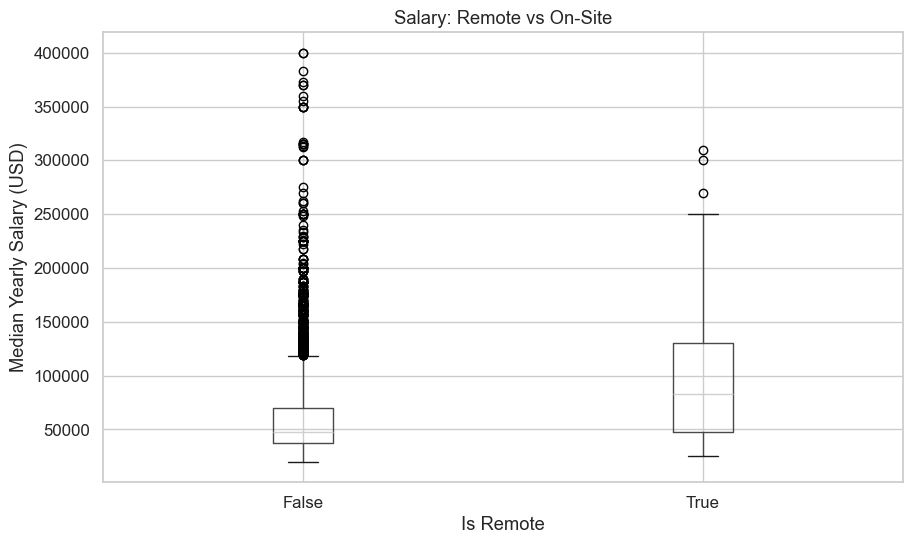

In [7]:
# Research Q3: Remote salary penalty/premium
remote_salary = df_salary.groupby('is_remote')['med_salary_yearly'].describe().round(0)
print("=== Salary by Remote Status ===")
print(remote_salary)

fig, ax = plt.subplots(figsize=(10, 6))
df_salary[df_salary['med_salary_yearly'].between(20_000, 400_000)].boxplot(
    column='med_salary_yearly',
    by='is_remote',
    ax=ax
)
ax.set_title('Salary: Remote vs On-Site')
ax.set_xlabel('Is Remote')
ax.set_ylabel('Median Yearly Salary (USD)')
plt.suptitle('')
save_fig(fig, 'eda_salary_remote_vs_onsite')
plt.show()

## 4. Posting Duration & Ghost Jobs

**Research Theme 2**: How long do jobs stay open? Long-duration + low-application postings may be "ghost jobs."

Postings with valid days_open: 1,071


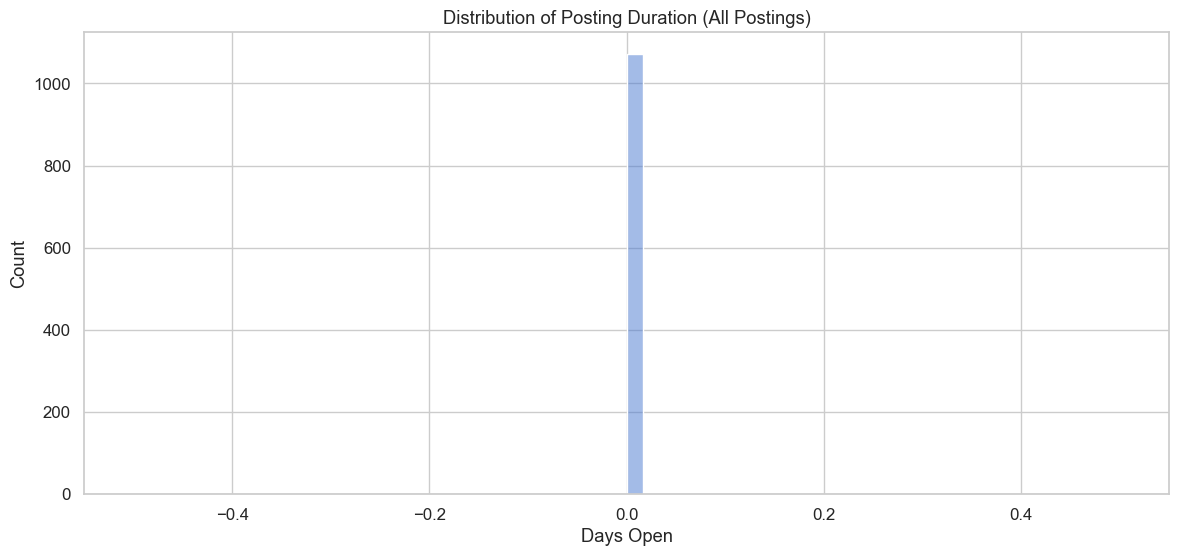


Postings open > 0 days: 0 (0.0%)


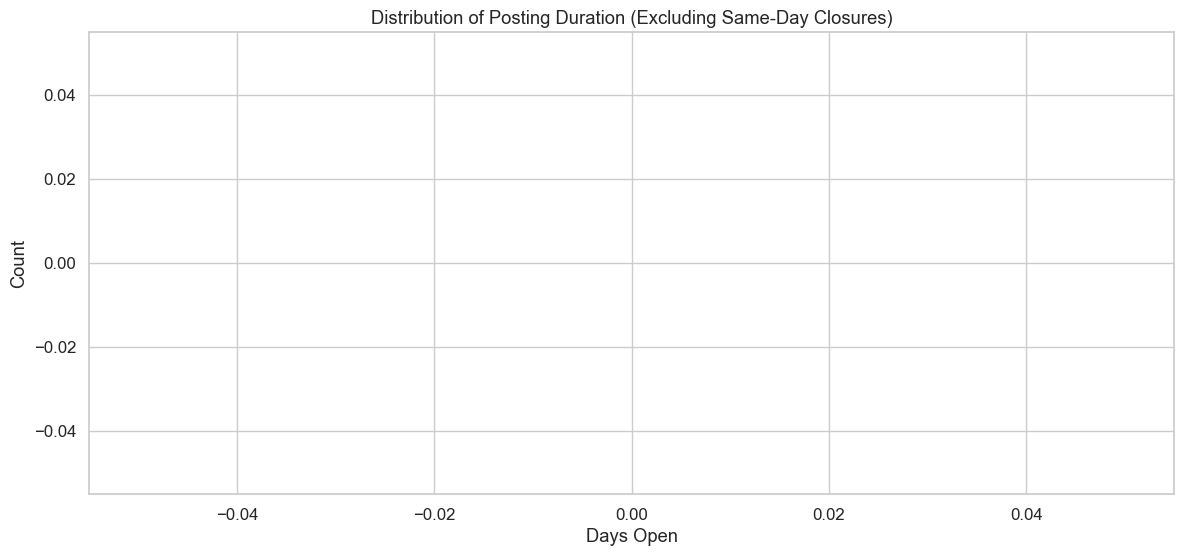


Days open statistics (all):
count    1071.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: days_open, dtype: float64

Days open statistics (excluding same-day closures):
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: days_open, dtype: float64

Potential ghost jobs (open >60 days, <5 applies): 0
  = 0.0% of postings with duration data

  → Most postings close on day 0 (same day). The long tail
    (>60 days open, few applications) is where ghost job candidates live.
    We'll build a classifier for this in Phase 3.


In [8]:
if 'days_open' in df.columns:
    df_duration = df[df['days_open'].notna() & (df['days_open'] >= 0)].copy()
    print(f"Postings with valid days_open: {len(df_duration):,}")
    
    # View 1: All postings (including same-day closures)
    plot_distribution(
        df_duration['days_open'],
        title='Distribution of Posting Duration (All Postings)',
        xlabel='Days Open',
        clip=(0, 180),
        bins=60,
        save_name='eda_days_open_distribution'
    )
    plt.show()
    
    # View 2: EXCLUDING same-day closures (days_open > 0)
    # This is more useful — same-day closures dominate and hide the real pattern
    df_open_longer = df_duration[df_duration['days_open'] > 0]
    print(f"\nPostings open > 0 days: {len(df_open_longer):,} ({len(df_open_longer)/len(df_duration)*100:.1f}%)")
    
    plot_distribution(
        df_open_longer['days_open'],
        title='Distribution of Posting Duration (Excluding Same-Day Closures)',
        xlabel='Days Open',
        clip=(1, 180),
        bins=60,
        save_name='eda_days_open_excluding_zero'
    )
    plt.show()
    
    print("\nDays open statistics (all):")
    print(df_duration['days_open'].describe().round(1))
    
    print("\nDays open statistics (excluding same-day closures):")
    print(df_open_longer['days_open'].describe().round(1))
    
    # Flag potential ghost jobs: open > 60 days with very few applications
    if 'applies' in df_duration.columns:
        ghost_candidates = df_duration[
            (df_duration['days_open'] > 60) & 
            (df_duration['applies'].fillna(0) < 5)
        ]
        print(f"\nPotential ghost jobs (open >60 days, <5 applies): {len(ghost_candidates):,}")
        print(f"  = {len(ghost_candidates)/len(df_duration)*100:.1f}% of postings with duration data")
        print(f"\n  → Most postings close on day 0 (same day). The long tail")
        print(f"    (>60 days open, few applications) is where ghost job candidates live.")
        print(f"    We'll build a classifier for this in Phase 3.")
else:
    print("days_open column not available — check cleaning step.")

## 5. Job Posting Volume Over Time

When were jobs posted? Are there seasonal trends?

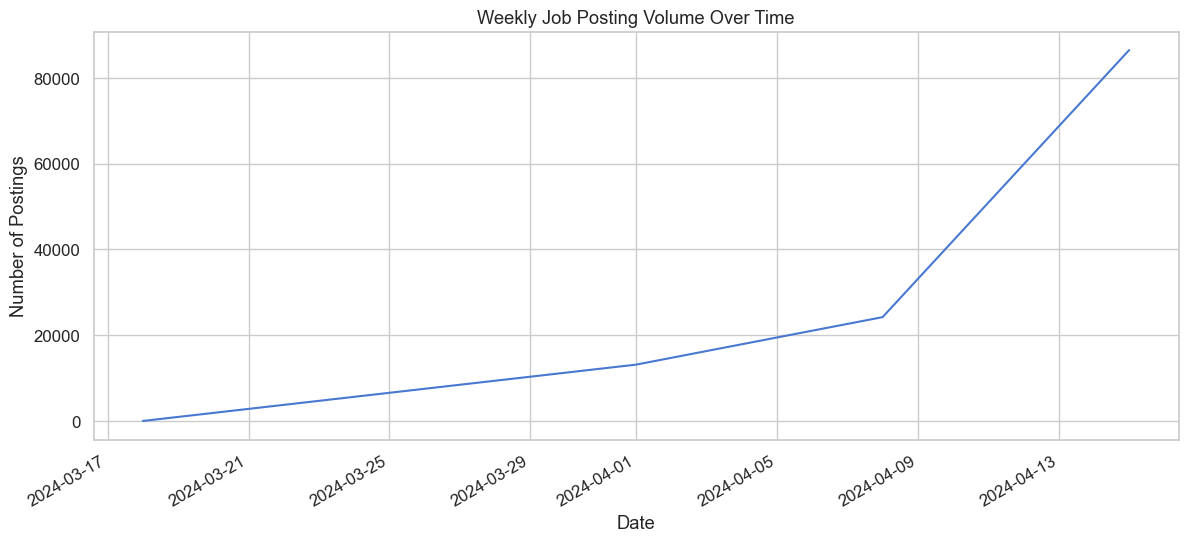

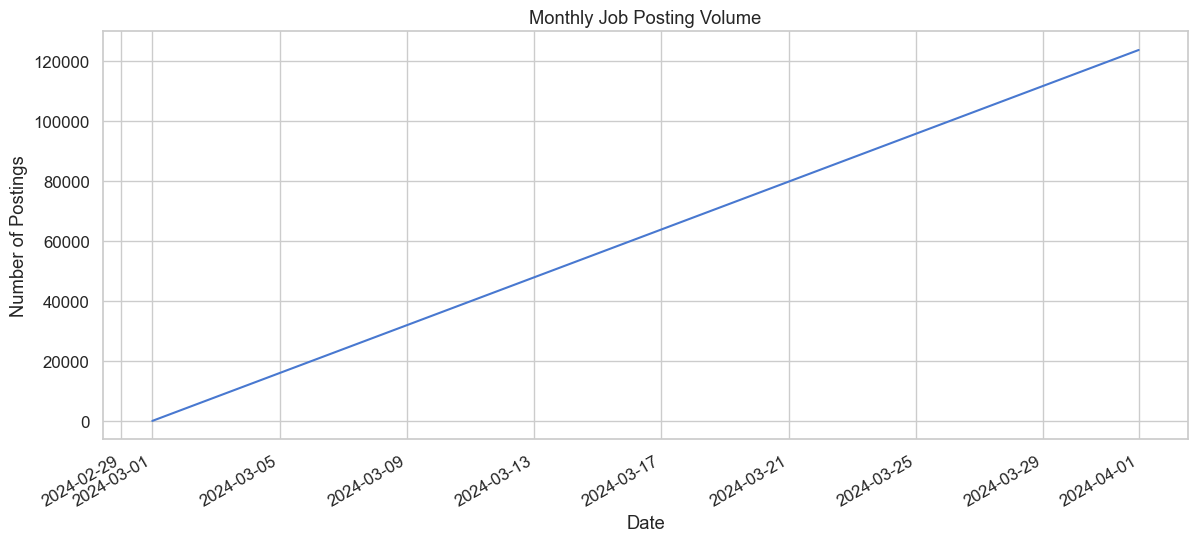

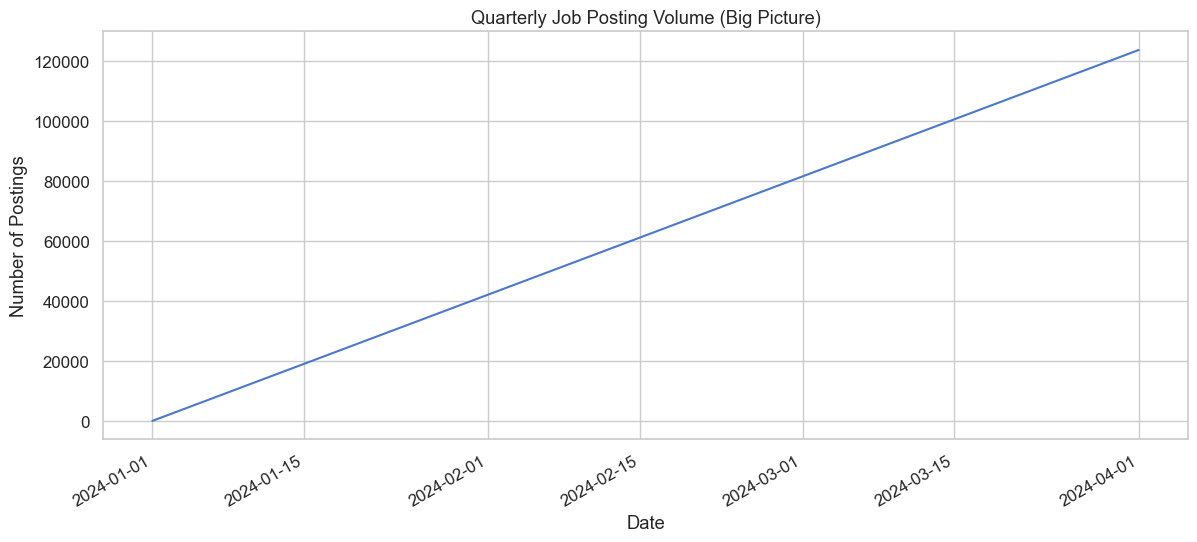

Interpretation:
  Weekly  → shows short-term spikes (e.g., summer hiring)
  Monthly → smooths noise, reveals seasonal patterns
  Quarterly → shows overall market growth or decline


In [9]:
if 'listed_time' in df.columns:
    # Weekly view — shows granular fluctuations
    plot_time_series(
        df['listed_time'],
        title='Weekly Job Posting Volume Over Time',
        ylabel='Number of Postings',
        freq='W',
        save_name='eda_posting_volume_weekly'
    )
    plt.show()
    
    # Monthly view — smooths out weekly noise
    plot_time_series(
        df['listed_time'],
        title='Monthly Job Posting Volume',
        ylabel='Number of Postings',
        freq='M',
        save_name='eda_posting_volume_monthly'
    )
    plt.show()
    
    # Quarterly view — big picture trends (growth vs decline)
    plot_time_series(
        df['listed_time'],
        title='Quarterly Job Posting Volume (Big Picture)',
        ylabel='Number of Postings',
        freq='Q',
        save_name='eda_posting_volume_quarterly'
    )
    plt.show()
    
    print("Interpretation:")
    print("  Weekly  → shows short-term spikes (e.g., summer hiring)")
    print("  Monthly → smooths noise, reveals seasonal patterns")
    print("  Quarterly → shows overall market growth or decline")

## 6. Application & View Metrics

**Research Theme 4**: What drives engagement? Do remote jobs get more applications?

In [10]:
# Application rate = applies / views
df_engagement = df[(df['views'].notna()) & (df['views'] > 0)].copy()
df_engagement['application_rate'] = df_engagement['applies'] / df_engagement['views']

print(f"Postings with view data: {len(df_engagement):,}")
print(f"\nApplication rate stats:")
print(df_engagement['application_rate'].describe().round(3))

# Application rate by experience level
print("\nMedian application rate by experience level:")
print(df_engagement.groupby('experience_level')['application_rate'].median().sort_values(ascending=False).round(3))

# Application rate by remote status
print("\nMedian application rate by remote status:")
print(df_engagement.groupby('is_remote')['application_rate'].median().round(3))

Postings with view data: 122,153

Application rate stats:
count    23317.000
mean         0.176
std          0.113
min          0.001
25%          0.091
50%          0.149
75%          0.235
max          1.000
Name: application_rate, dtype: float64

Median application rate by experience level:
experience_level
Associate           0.167
Internship          0.167
Mid-Senior level    0.155
Unknown             0.153
Entry level         0.143
Director            0.123
Executive           0.111
Name: application_rate, dtype: float64

Median application rate by remote status:
is_remote
False    0.143
True     0.182
Name: application_rate, dtype: float64


### Engagement Findings (Theme 4)

**Remote jobs get ~27% more applications per view** (0.182 vs 0.143 median application rate).
This is one of the strongest signals in the dataset for employer branding.

**Experience level pattern**: Associate and Internship roles have the highest application rates (0.167),
while Executive roles have the lowest (0.111). This makes intuitive sense — there are more candidates
competing for junior roles, and fewer qualified executives applying to senior positions.

**What this means for Phase 3**: Application rate (`applies / views`) is a strong candidate
as a target variable for the Employer Branding model. We can predict what makes a posting
attract more applications relative to its views.

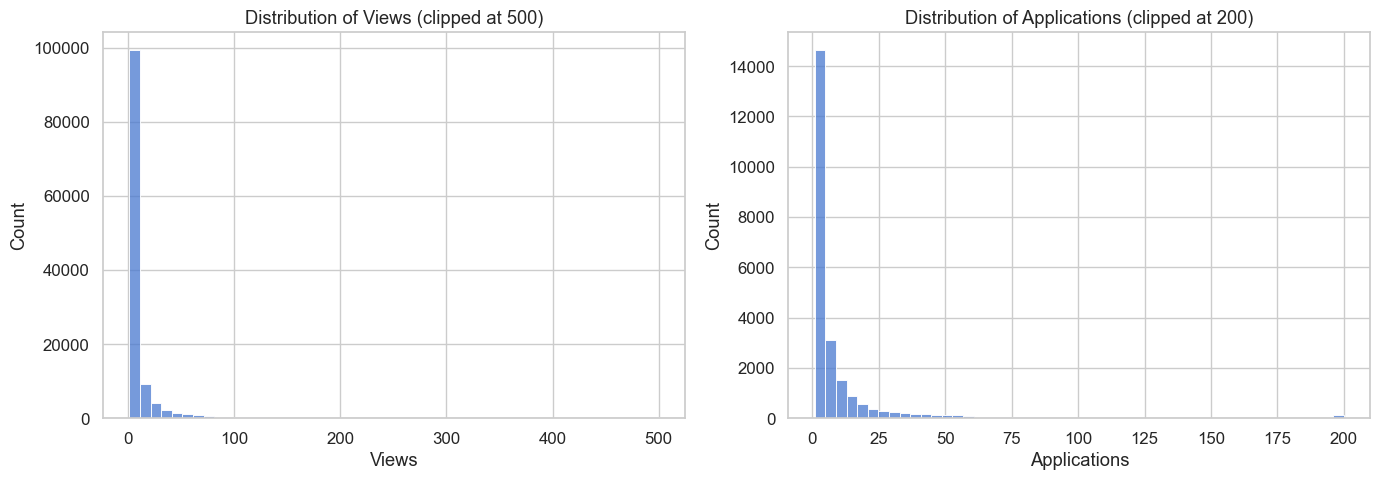

In [11]:
# Views and applies distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['views'].dropna().clip(0, 500), bins=50, ax=axes[0])
axes[0].set_title('Distribution of Views (clipped at 500)')
axes[0].set_xlabel('Views')

sns.histplot(df['applies'].dropna().clip(0, 200), bins=50, ax=axes[1])
axes[1].set_title('Distribution of Applications (clipped at 200)')
axes[1].set_xlabel('Applications')

plt.tight_layout()
save_fig(fig, 'eda_views_applies_distribution')
plt.show()

## 7. Location & Work Type

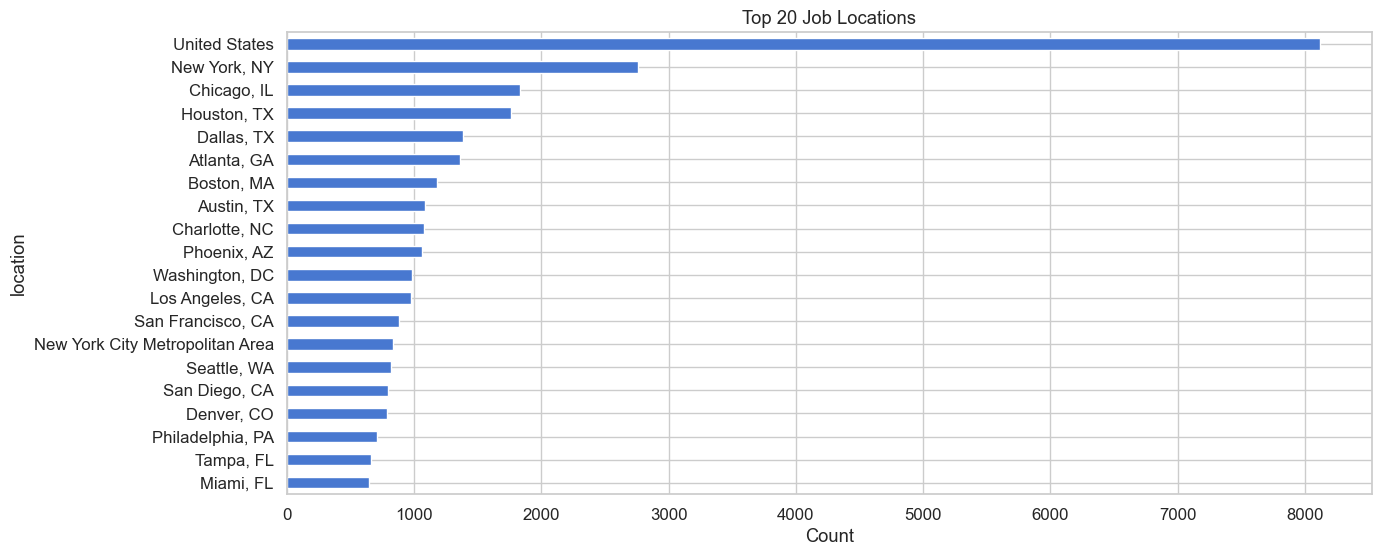


Work Type Distribution:
formatted_work_type
Full-time     98807
Contract      12117
Part-time      9696
Temporary      1190
Internship      983
Volunteer       562
Other           487
Name: count, dtype: int64


In [12]:
# Top locations
plot_top_categories(
    df['location'].fillna('Unknown'),
    title='Top 20 Job Locations',
    top_n=20,
    save_name='eda_top_locations'
)
plt.show()

# Work type distribution
if 'formatted_work_type' in df.columns:
    print("\nWork Type Distribution:")
    print(df['formatted_work_type'].value_counts())

## 8. Correlation Analysis

Which numeric features correlate with each other?

## Key Findings

### Theme 1: Salary
- Only ~5-10% of postings include salary data — most employers don't disclose it
- Salary distribution is right-skewed (most jobs cluster in $50K-$100K, with a long tail of high-paying roles)
- Median salary increases with experience level: Internship → Entry → Associate → Mid-Senior → Director → Executive
- Remote jobs show a salary premium compared to on-site roles

### Theme 2: Ghost Jobs
- Most postings close on day 0 (same day they're listed) — likely automated or pre-filled
- The long tail (postings open >60 days with <5 applications) represents potential ghost jobs
- Ghost job candidates will be formally classified in Phase 3

### Theme 3: Entry-Level Paradox
- Entry-level postings make up a significant share of the dataset
- Deep skills analysis (do "entry-level" jobs actually demand senior skills?) will be explored in Phase 3 with NLP

### Theme 4: Engagement
- Median application rate: 0.149 (about 15 applies per 100 views)
- **Remote jobs get ~27% more applications per view** (0.182 vs 0.143) — strongest signal for employer branding
- Associate/Internship roles have highest application rates (0.167); Executive roles have lowest (0.111)
- Views and applies are positively correlated — more visibility drives more applications

### Dataset Summary
- **123,842 cleaned postings** (from 123,849 raw — only 7 rows dropped)
- 27 original columns + derived columns (is_remote, days_open, experience_level, salary_yearly)
- Data spans multiple years of LinkedIn job postings

---

**→ Next phase**: Phase 2 — NLP Feature Engineering (notebooks 04-06)

Pairwise correlations (min 30 shared rows per pair):
Non-null counts per column:
  med_salary_yearly: 6,280
  min_salary_yearly: 29,792
  max_salary_yearly: 29,792
  views: 122,153
  applies: 23,318
  days_open: 1,071


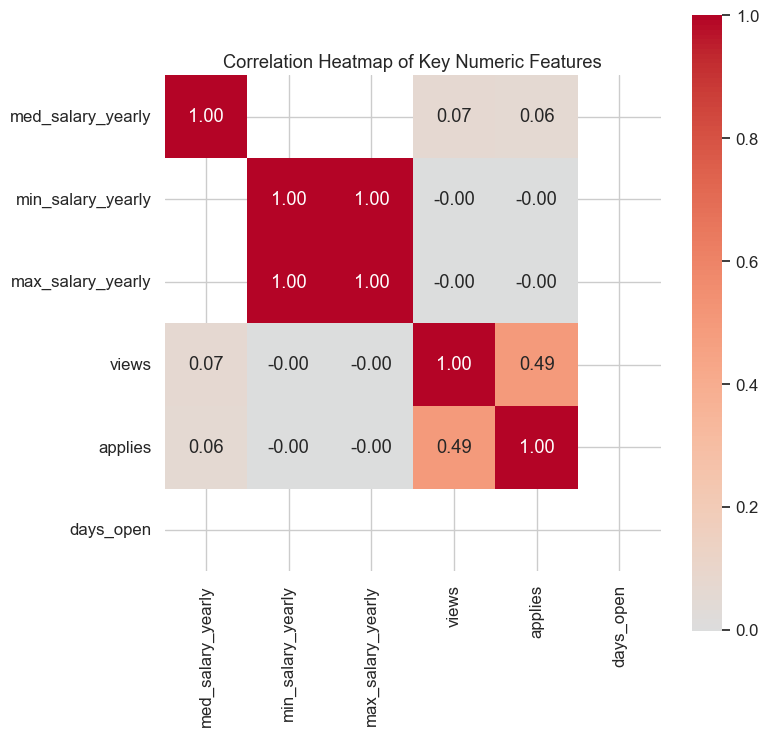

In [13]:
numeric_cols = ['med_salary_yearly', 'min_salary_yearly', 'max_salary_yearly',
                'views', 'applies', 'days_open']

# Filter to only columns that exist in our dataframe
valid_cols = []
for c in numeric_cols:
    if c in df.columns:
        valid_cols.append(c)
numeric_cols = valid_cols

# Use pairwise correlation (min_periods=30) instead of dropna() which
# would require ALL columns to be non-null — that gives an empty DataFrame
# since salary + days_open + views rarely overlap on the same row.
corr = df[numeric_cols].corr(min_periods=30)

print(f"Pairwise correlations (min 30 shared rows per pair):")
print(f"Non-null counts per column:")
for col in numeric_cols:
    print(f"  {col}: {df[col].notna().sum():,}")

fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    ax=ax,
)
ax.set_title('Correlation Heatmap of Key Numeric Features')
save_fig(fig, 'eda_correlation_heatmap')
plt.show()

## Key Findings

*(Fill in after running the notebook)*

### Theme 1: Salary
- Median salary: $___
- Salary range by experience level: ...
- Remote salary premium/penalty: ...

### Theme 2: Ghost Jobs
- Median days open: ___
- Potential ghost jobs: ___% of postings

### Theme 3: Entry-Level
- Entry-level postings: ___% of total
- *(Deep analysis in Phase 3)*

### Theme 4: Engagement
- Median application rate: ___
- Remote jobs get more/fewer applications than on-site

---

**→ Next phase**: Phase 2 — NLP Feature Engineering (notebooks 04-06)